In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from reporting.test import (
    CLASSIFIER_ORDER,
    DEFAULT_ARTIFACTS_DIRECTORY,
    DEFAULT_FEATURE_IMPORTANCE_TOP_N,
    METRIC_DISPLAY_NAMES,
    PRIMARY_TEST_METRIC,
    TestExperimentArtifacts,
    TestStatistics,
    compile_dataset_feature_importances,
    compile_test_statistics,
    display_test_confusion_matrices,
    load_test_experiment_artifacts,
    plot_dataset_feature_importance_heatmap,
    plot_dataset_feature_importances,
    plot_metric_comparison,
    plot_per_class_metric_heatmap,
    plot_test_seed_metric,
    prepare_dataset_feature_importance_table,
)


In [2]:
# ============================================================================
# Configuration
# ============================================================================

ARTIFACTS_DIRECTORY = DEFAULT_ARTIFACTS_DIRECTORY
DATASET_NAME = "GENIS"

# ``None`` means: use the first persisted seed for each classifier.
REPRESENTATIVE_SEED: int | None = None


In [3]:
# ============================================================================
# Small notebook helpers
# ============================================================================


def _metadata_integer(
    metadata: dict[str, object],
    key: str,
) -> int | None:
    """Return a validated integer metadata field."""
    value = metadata.get(key)

    if value is None:
        return None

    if isinstance(value, bool) or not isinstance(value, int):
        raise TypeError(
            f"Metadata field {key!r} must be an integer.",
        )

    return value


def _classifier_label(
    statistics: TestStatistics,
) -> str:
    """Return the display name of the classifier from the summary table."""
    if statistics.summary_table.empty:
        raise ValueError("Test summary table is empty.")

    return str(
        statistics.summary_table["Classifier"].iat[0],
    )

In [4]:
# ============================================================================
# Load persisted GENIS test artifacts
# ============================================================================

artifacts_by_classifier: dict[str, TestExperimentArtifacts] = {}

for classifier_name in CLASSIFIER_ORDER:
    artifacts_by_classifier[classifier_name] = load_test_experiment_artifacts(
        dataset_name=DATASET_NAME,
        classifier_name=classifier_name,
        artifacts_directory=ARTIFACTS_DIRECTORY,
    )


statistics_by_classifier: dict[str, TestStatistics] = {
    classifier_name: compile_test_statistics(
        artifacts=artifacts_by_classifier[classifier_name],
        include_validation_comparison=True,
    )
    for classifier_name in CLASSIFIER_ORDER
}


In [5]:
# ============================================================================
# Experiment information
# ============================================================================

experiment_rows: list[dict[str, object]] = []

for classifier_name in CLASSIFIER_ORDER:
    experiment = artifacts_by_classifier[classifier_name]
    metadata = experiment.metadata

    test_row_count = _metadata_integer(
        metadata,
        "test_row_count",
    )
    seed_count = _metadata_integer(
        metadata,
        "seed_count",
    )

    seed_values = tuple(
        sorted(int(seed) for seed in experiment.seed_metrics["seed"].unique())
    )

    experiment_rows.append(
        {
            "Dataset": experiment.dataset_name,
            "Classifier": _classifier_label(
                statistics_by_classifier[classifier_name],
            ),
            "Test observations": (
                test_row_count if test_row_count is not None else pd.NA
            ),
            "Seeds": (seed_count if seed_count is not None else len(seed_values)),
            "Seed values": ", ".join(str(seed) for seed in seed_values),
        },
    )


genis_experiment_table = pd.DataFrame(
    experiment_rows,
)

display(genis_experiment_table)


,Dataset,Classifier,Test observations,Seeds,Seed values
0,GENIS,Decision Tree,73712,3,"27, 32, 59"
1,GENIS,Random Forest,73712,3,"27, 32, 59"
2,GENIS,XGBoost,73712,3,"27, 32, 59"


In [6]:
# ============================================================================
# Main final-test metrics
# ============================================================================

genis_test_summary = pd.concat(
    [
        statistics_by_classifier[classifier_name].summary_table
        for classifier_name in CLASSIFIER_ORDER
    ],
    ignore_index=True,
).reset_index(drop=True)

display(genis_test_summary)

,Dataset,Classifier,Seeds,Accuracy,Precision,Recall,Macro F1,ROC-AUC,PR-AUC,MCC,Balanced Accuracy
0,GENIS,Decision Tree,3,0.999954778960 ± 0.000020722884,0.999860539654 ± 0.000048136353,0.999885193402 ± 0.000036499200,0.999872841351 ± 0.000039417183,0.999934247758 ± 0.000021980625,0.999757049687 ± 0.000074265820,0.999868197702 ± 0.000060397283,0.999885193402 ± 0.000036499200
1,GENIS,Random Forest,3,1.000000000000 ± 0.000000000000,1.000000000000 ± 0.000000000000,1.000000000000 ± 0.000000000000,1.000000000000 ± 0.000000000000,1.000000000000 ± 0.000000000000,1.000000000000 ± 0.000000000000,1.000000000000 ± 0.000000000000,1.000000000000 ± 0.000000000000
2,GENIS,XGBoost,3,1.000000000000 ± 0.000000000000,1.000000000000 ± 0.000000000000,1.000000000000 ± 0.000000000000,1.000000000000 ± 0.000000000000,1.000000000000 ± 0.000000000000,1.000000000000 ± 0.000000000000,1.000000000000 ± 0.000000000000,1.000000000000 ± 0.000000000000


In [7]:
# ============================================================================
# Selected configurations
# ============================================================================

configuration_tables: list[pd.DataFrame] = []

for classifier_name in CLASSIFIER_ORDER:
    statistics = statistics_by_classifier[classifier_name]

    configuration_table = statistics.selected_configuration_table.copy()

    configuration_table.insert(
        0,
        "Classifier",
        _classifier_label(statistics),
    )

    configuration_tables.append(
        configuration_table,
    )


genis_selected_configurations = pd.concat(
    configuration_tables,
    ignore_index=True,
).reset_index(drop=True)

display(genis_selected_configurations)

,Classifier,Configuration ID,criterion,max_depth,min_samples_leaf,min_samples_split,sampler,n_estimators,learning_rate,min_child_weight,subsample
0,Decision Tree,1cbc00d06004,gini,20,1.0,2.0,passthrough,NaN,NaN,NaN,NaN
1,Random Forest,7eb62a443ff7,NaN,None,1.0,2.0,passthrough,200.0,NaN,NaN,NaN
2,XGBoost,17edbfb766e1,NaN,6,NaN,NaN,passthrough,200.0,0.1,1.0,0.8


In [8]:
# ============================================================================
# Test metrics by seed
# ============================================================================

genis_seed_metrics = pd.concat(
    [
        statistics_by_classifier[classifier_name].seed_metrics_table
        for classifier_name in CLASSIFIER_ORDER
    ],
    ignore_index=True,
).reset_index(drop=True)

display(genis_seed_metrics)


,Dataset,Classifier,Seed,Configuration ID,Accuracy,Precision,Recall,Macro F1,ROC-AUC,PR-AUC,MCC,Balanced Accuracy
0,GENIS,Decision Tree,27,1cbc00d06004,0.999972867376,0.999907952872,0.999926462209,0.999917194244,0.999959569818,0.999841198237,0.999920917208,0.999926462209
1,GENIS,Decision Tree,32,1cbc00d06004,0.999932168439,0.999811711370,0.999871965463,0.999841814482,0.999920089121,0.999700668834,0.999802299082,0.999871965463
2,GENIS,Decision Tree,59,1cbc00d06004,0.999959301064,0.999861954721,0.999857152533,0.999859515327,0.999923084336,0.999729281989,0.999881376817,0.999857152533
3,GENIS,Random Forest,27,7eb62a443ff7,1.000000000000,1.000000000000,1.000000000000,1.000000000000,1.000000000000,1.000000000000,1.000000000000,1.000000000000
4,GENIS,Random Forest,32,7eb62a443ff7,1.000000000000,1.000000000000,1.000000000000,1.000000000000,1.000000000000,1.000000000000,1.000000000000,1.000000000000
5,GENIS,Random Forest,59,7eb62a443ff7,1.000000000000,1.000000000000,1.000000000000,1.000000000000,1.000000000000,1.000000000000,1.000000000000,1.000000000000
6,GENIS,XGBoost,27,17edbfb766e1,1.000000000000,1.000000000000,1.000000000000,1.000000000000,1.000000000000,1.000000000000,1.000000000000,1.000000000000
7,GENIS,XGBoost,32,17edbfb766e1,1.000000000000,1.000000000000,1.000000000000,1.000000000000,1.000000000000,1.000000000000,1.000000000000,1.000000000000
8,GENIS,XGBoost,59,17edbfb766e1,1.000000000000,1.000000000000,1.000000000000,1.000000000000,1.000000000000,1.000000000000,1.000000000000,1.000000000000


In [9]:
# ============================================================================
# Per-class test metrics
# ============================================================================

genis_per_class_metrics = pd.concat(
    [
        statistics_by_classifier[classifier_name].per_class_metrics_table
        for classifier_name in CLASSIFIER_ORDER
    ],
    ignore_index=True,
).reset_index(drop=True)

display(genis_per_class_metrics)


,Classifier,Class,Support,Precision,Recall,F1
0,Decision Tree,benign,5430,0.999447796295 ± 0.000184026488,0.999938612646 ± 0.000106326017,0.999693142345 ± 0.000140609857
1,Decision Tree,bruteforce,3607,1.000000000000 ± 0.000000000000,0.999630348396 ± 0.000160063839,0.999815135759 ± 0.000080065213
2,Decision Tree,dos,59128,0.999994362322 ± 0.000009764744,0.999971812565 ± 0.000019528828,0.999983087301 ± 0.000014646910
3,Decision Tree,recon,5547,1.000000000000 ± 0.000000000000,1.000000000000 ± 0.000000000000,1.000000000000 ± 0.000000000000
4,Random Forest,benign,5430,1.000000000000 ± 0.000000000000,1.000000000000 ± 0.000000000000,1.000000000000 ± 0.000000000000
5,Random Forest,bruteforce,3607,1.000000000000 ± 0.000000000000,1.000000000000 ± 0.000000000000,1.000000000000 ± 0.000000000000
6,Random Forest,dos,59128,1.000000000000 ± 0.000000000000,1.000000000000 ± 0.000000000000,1.000000000000 ± 0.000000000000
7,Random Forest,recon,5547,1.000000000000 ± 0.000000000000,1.000000000000 ± 0.000000000000,1.000000000000 ± 0.000000000000
8,XGBoost,benign,5430,1.000000000000 ± 0.000000000000,1.000000000000 ± 0.000000000000,1.000000000000 ± 0.000000000000
9,XGBoost,bruteforce,3607,1.000000000000 ± 0.000000000000,1.000000000000 ± 0.000000000000,1.000000000000 ± 0.000000000000


In [10]:
# ============================================================================
# Validation versus test
# ============================================================================

validation_comparison_tables: list[pd.DataFrame] = []

for classifier_name in CLASSIFIER_ORDER:
    statistics = statistics_by_classifier[classifier_name]
    comparison = statistics.validation_vs_test_table

    if comparison is None:
        continue

    comparison = comparison.copy()

    comparison.insert(
        0,
        "Classifier",
        _classifier_label(statistics),
    )

    validation_comparison_tables.append(
        comparison,
    )


if validation_comparison_tables:
    genis_validation_vs_test = pd.concat(
        validation_comparison_tables,
        ignore_index=True,
    ).reset_index(drop=True)

    display(genis_validation_vs_test)
else:
    genis_validation_vs_test = None


,Classifier,Metric,validation_mean,validation_std,test_mean,test_std,Validation,Test,Test − validation
0,Decision Tree,Accuracy,0.999942,1.356642e-05,0.999955,0.000021,0.999942342426 ± 0.000013566421,0.999954778960 ± 0.000020722884,1.243653e-05
1,Decision Tree,Precision,0.999846,3.459487e-05,0.999861,0.000048,0.999845575897 ± 0.000034594866,0.999860539654 ± 0.000048136353,1.496376e-05
2,Decision Tree,Recall,0.999828,4.443604e-05,0.999885,0.000036,0.999827613006 ± 0.000044436042,0.999885193402 ± 0.000036499200,5.758040e-05
3,Decision Tree,Macro F1,0.999837,3.913197e-05,0.999873,0.000039,0.999836575273 ± 0.000039131970,0.999872841351 ± 0.000039417183,3.626608e-05
4,Decision Tree,ROC-AUC,0.999895,2.712601e-05,0.999934,0.000022,0.999895403769 ± 0.000027126013,0.999934247758 ± 0.000021980625,3.884399e-05
5,Decision Tree,PR-AUC,0.999688,7.500374e-05,0.999757,0.000074,0.999687641929 ± 0.000075003741,0.999757049687 ± 0.000074265820,6.940776e-05
6,Decision Tree,MCC,0.999832,3.954534e-05,0.999868,0.000060,0.999831930615 ± 0.000039545342,0.999868197702 ± 0.000060397283,3.626709e-05
7,Decision Tree,Balanced Accuracy,0.999828,4.443604e-05,0.999885,0.000036,0.999827613006 ± 0.000044436042,0.999885193402 ± 0.000036499200,5.758040e-05
8,Random Forest,Accuracy,0.999977,5.180745e-06,1.000000,0.000000,0.999977389188 ± 0.000005180745,1.000000000000 ± 0.000000000000,2.261081e-05
9,Random Forest,Precision,0.999955,7.580723e-06,1.000000,0.000000,0.999954628366 ± 0.000007580723,1.000000000000 ± 0.000000000000,4.537163e-05


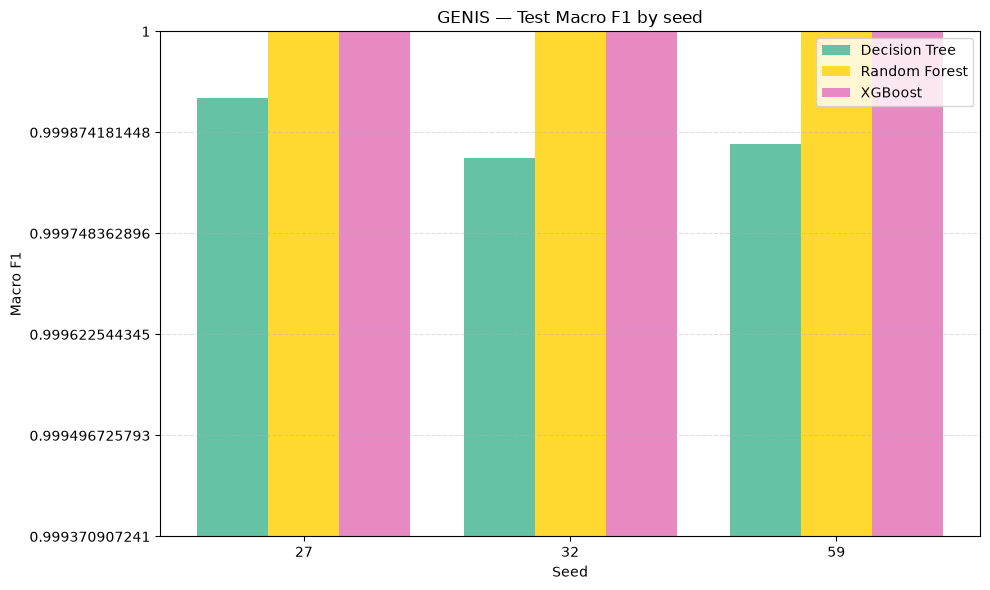

In [11]:
# ============================================================================
# Seed variability — primary test metric
# ============================================================================

seed_metric_plot_data = pd.concat(
    [
        artifacts_by_classifier[classifier_name].seed_metrics
        for classifier_name in CLASSIFIER_ORDER
    ],
    ignore_index=True,
).reset_index(drop=True)

figure = plot_test_seed_metric(
    seed_metrics=seed_metric_plot_data,
    metric=PRIMARY_TEST_METRIC,
    title=f"{DATASET_NAME} — Test {METRIC_DISPLAY_NAMES[PRIMARY_TEST_METRIC]} by seed",
)

display(figure)
plt.close(figure)


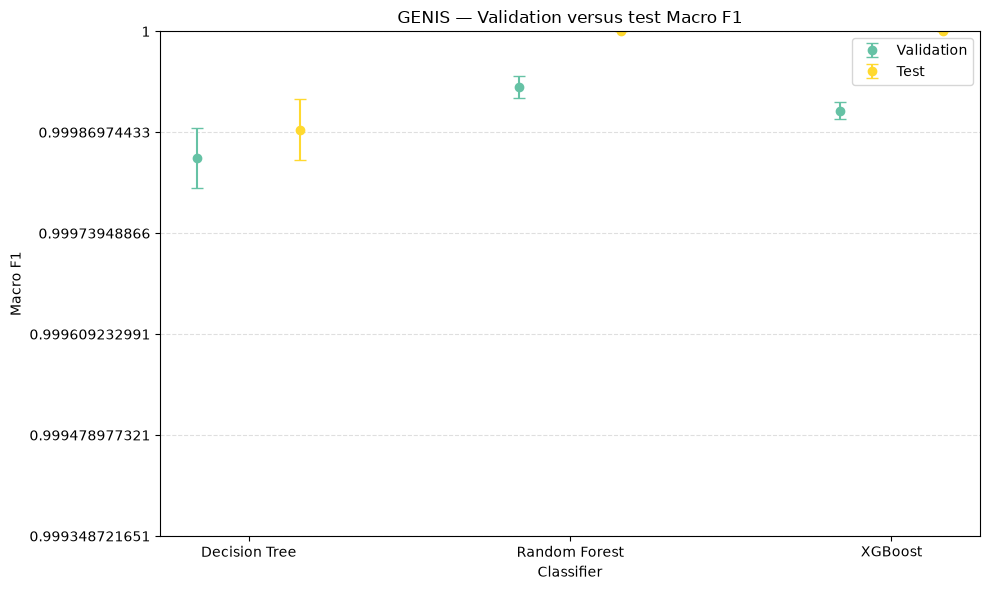

In [12]:
# ============================================================================
# Validation versus test — primary metric
# ============================================================================

if genis_validation_vs_test is not None:
    macro_f1_comparison = genis_validation_vs_test.loc[
        genis_validation_vs_test["Metric"] == METRIC_DISPLAY_NAMES[PRIMARY_TEST_METRIC],
        [
            "Classifier",
            "validation_mean",
            "validation_std",
            "test_mean",
            "test_std",
        ],
    ].copy()

    macro_f1_comparison = macro_f1_comparison.rename(
        columns={
            "Classifier": "classifier",
        },
    )

    figure = plot_metric_comparison(
        data_frame=macro_f1_comparison,
        metric=PRIMARY_TEST_METRIC,
        title=(
            f"{DATASET_NAME} — "
            f"Validation versus test {METRIC_DISPLAY_NAMES[PRIMARY_TEST_METRIC]}"
        ),
    )

    display(figure)
    plt.close(figure)


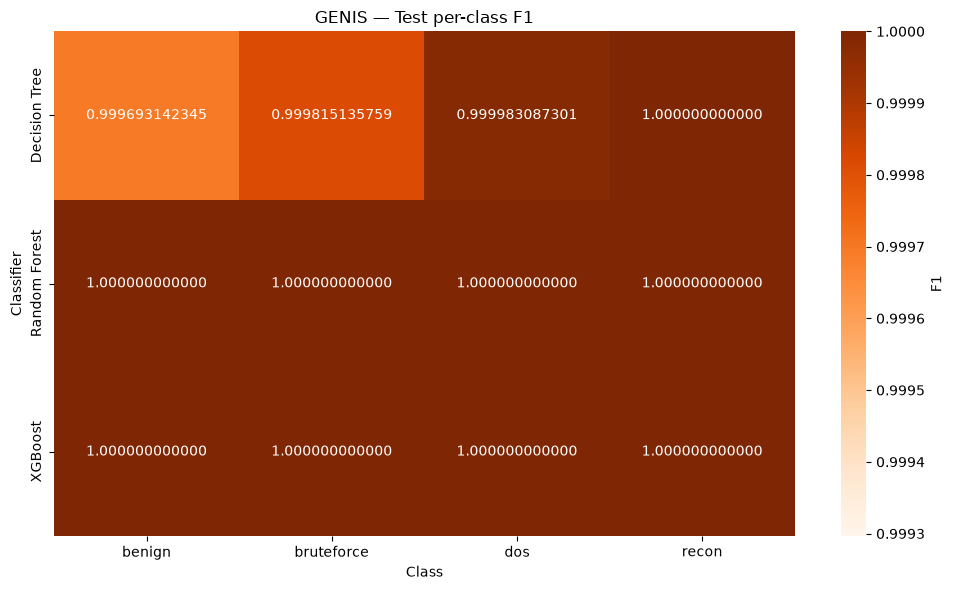

In [13]:
# ============================================================================
# Per-class F1 heatmap
# ============================================================================

per_class_plot_data = pd.concat(
    [
        artifacts_by_classifier[classifier_name].per_class_metrics
        for classifier_name in CLASSIFIER_ORDER
    ],
    ignore_index=True,
).reset_index(drop=True)

figure = plot_per_class_metric_heatmap(
    per_class_metrics=per_class_plot_data,
    metric="f1",
    title=f"{DATASET_NAME} — Test per-class F1",
)

display(figure)
plt.close(figure)


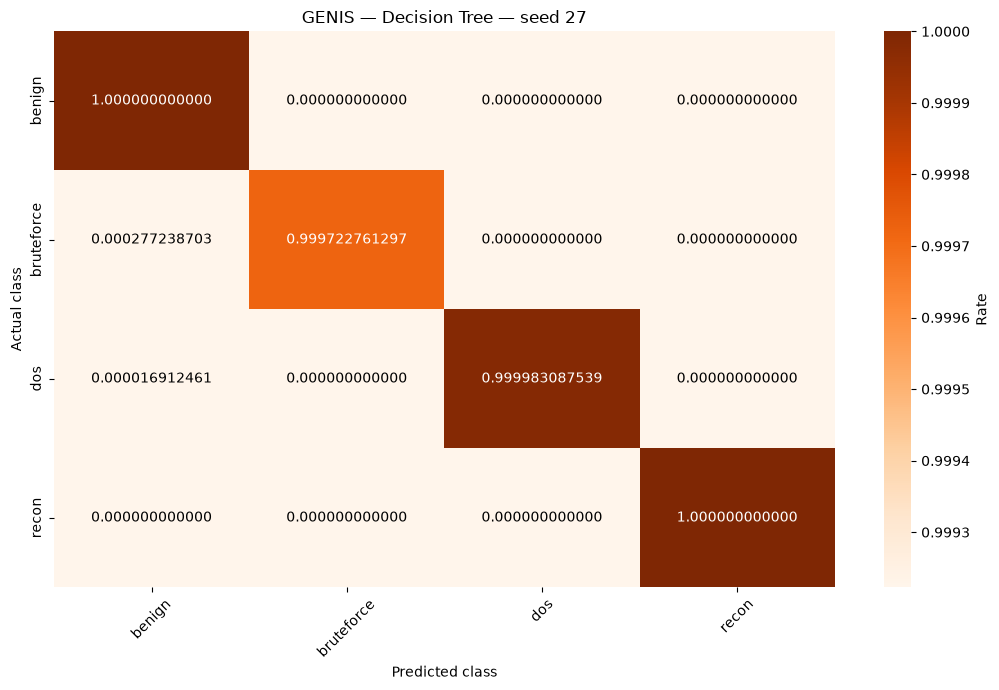

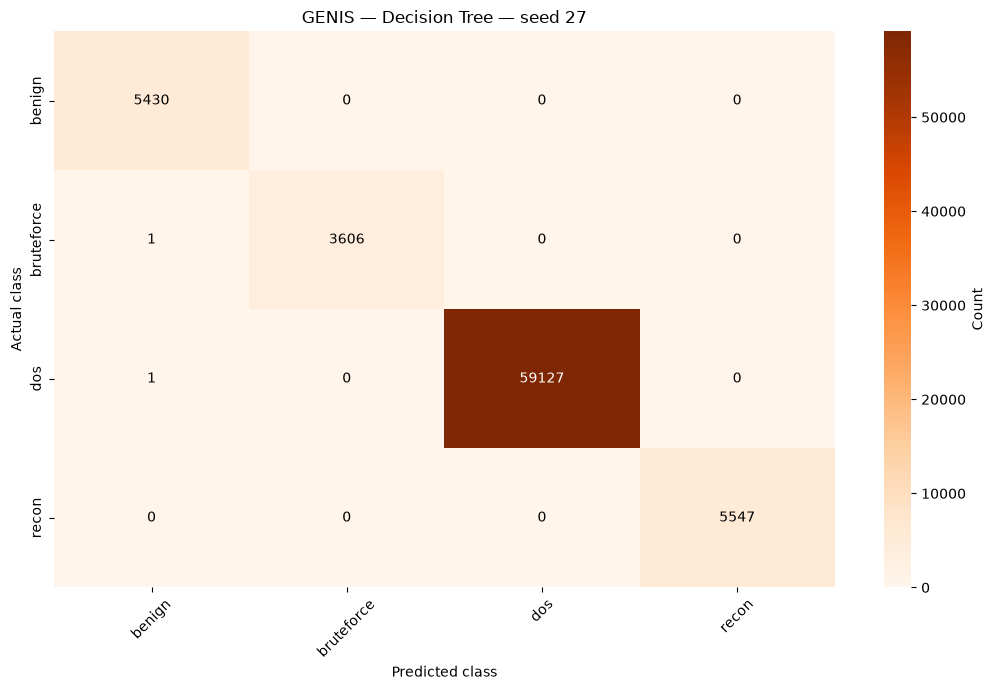

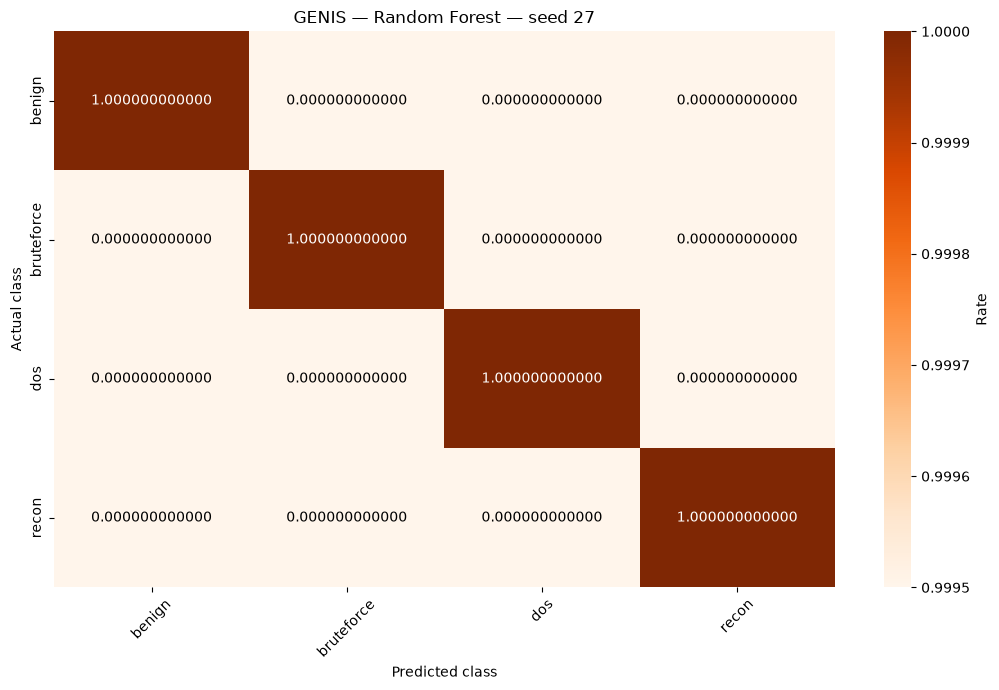

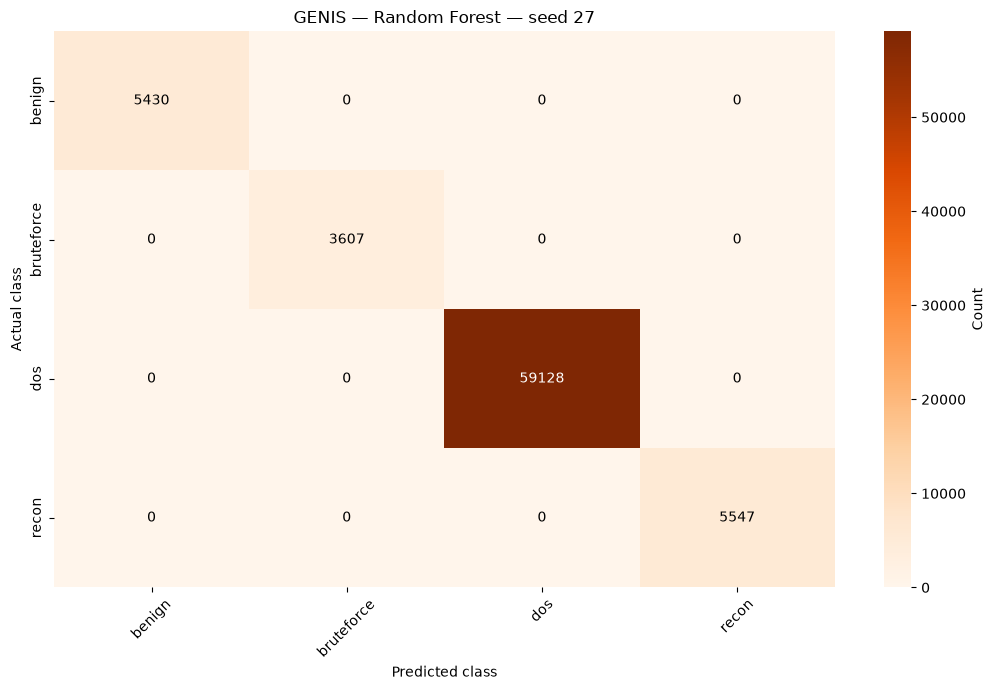

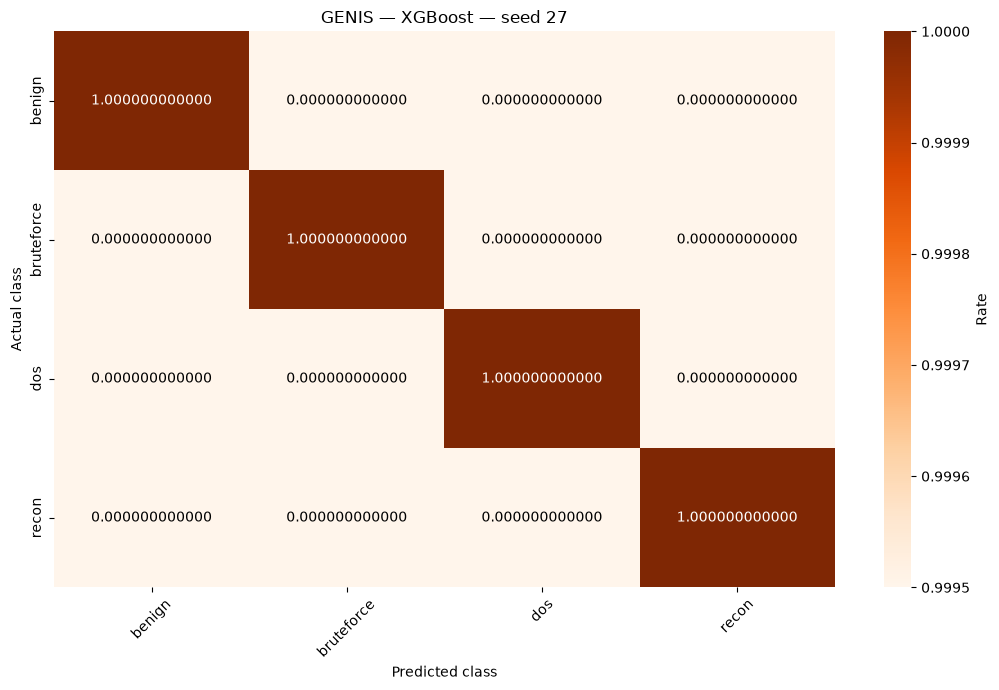

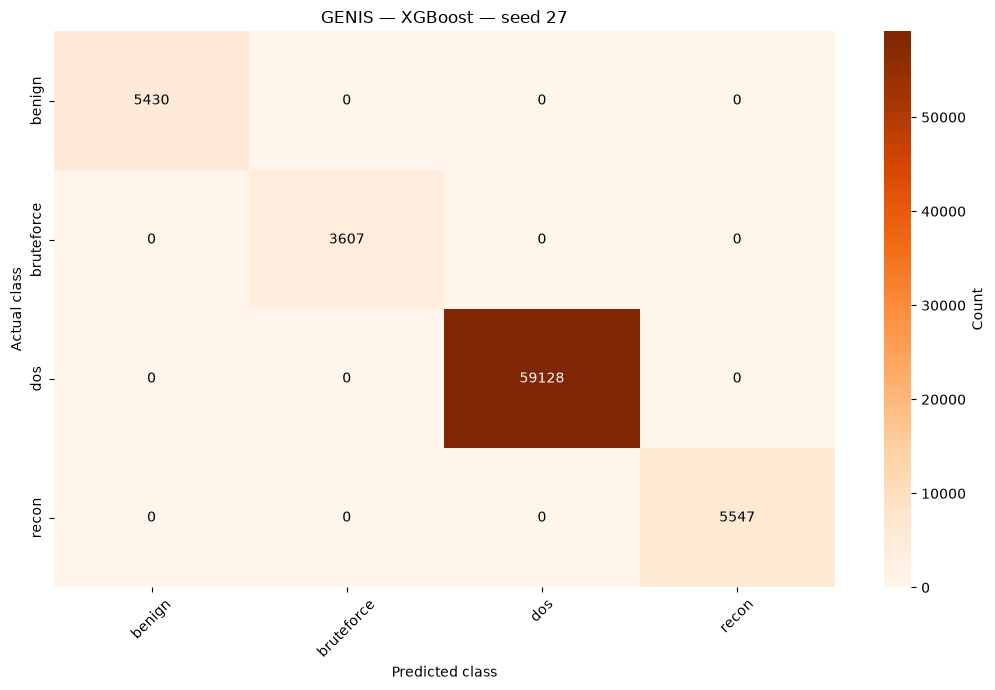

In [14]:
# ============================================================================
# Persisted confusion matrices
# ============================================================================

for classifier_name in CLASSIFIER_ORDER:
    experiment = artifacts_by_classifier[classifier_name]

    persisted_seeds = tuple(
        sorted(
            experiment.normalized_confusion_matrices,
        )
    )

    if not persisted_seeds:
        raise ValueError(
            f"No normalized confusion matrices were found for {classifier_name!r}.",
        )

    representative_seed = (
        REPRESENTATIVE_SEED if REPRESENTATIVE_SEED is not None else persisted_seeds[0]
    )

    display_test_confusion_matrices(
        experiment,
        normalized=True,
        seed=representative_seed,
    )

    display_test_confusion_matrices(
        experiment,
        normalized=False,
        seed=representative_seed,
    )


In [15]:
# ============================================================================
# Compact primary-metric table
# ============================================================================

primary_metric_column = METRIC_DISPLAY_NAMES[PRIMARY_TEST_METRIC]

genis_primary_metric_summary = genis_test_summary[
    [
        "Dataset",
        "Classifier",
        "Seeds",
        primary_metric_column,
    ]
].copy()

display(genis_primary_metric_summary)

,Dataset,Classifier,Seeds,Macro F1
0,GENIS,Decision Tree,3,0.999872841351 ± 0.000039417183
1,GENIS,Random Forest,3,1.000000000000 ± 0.000000000000
2,GENIS,XGBoost,3,1.000000000000 ± 0.000000000000


,Feature,Decision Tree,Random Forest,XGBoost
0,source_interpacket_time_maximum,0.446461241175 ± 0.002107531673,0.058710467851 ± 0.016962776610,0.040460638702 ± 0.001605578831
1,destination_port_category,0.142414263722 ± 0.000000000000,0.091538918408 ± 0.003479950987,0.383717503685 ± 0.017783253226
2,source_hops,0.168990043932 ± 0.002133659936,0.042771699706 ± 0.008805841368,0.136618132393 ± 0.003849162761
3,destination_minimum_packet_size,0.001206399215 ± 0.000000000000,0.009889956448 ± 0.000473270476,0.123884188632 ± 0.008767374003
4,source_maximum_packet_size,0.093235045267 ± 0.000030733952,0.029250265991 ± 0.002310814265,0.006596045879 ± 0.000455965147
...,...,...,...,...
62,flags_e,0.000000000000 ± 0.000000000000,0.000541276759 ± 0.000642281913,0.000012075140 ± 0.000011473180
63,state_int,0.000000000000 ± 0.000000000000,0.000298114736 ± 0.000161082521,0.000080229504 ± 0.000028824804
64,flags_e_s,0.000000000000 ± 0.000000000000,0.000125914022 ± 0.000058401434,0.000001770369 ± 0.000001542895
65,flags_e_star,0.000000000000 ± 0.000000000000,0.000017424523 ± 0.000004806746,0.000000000000 ± 0.000000000000


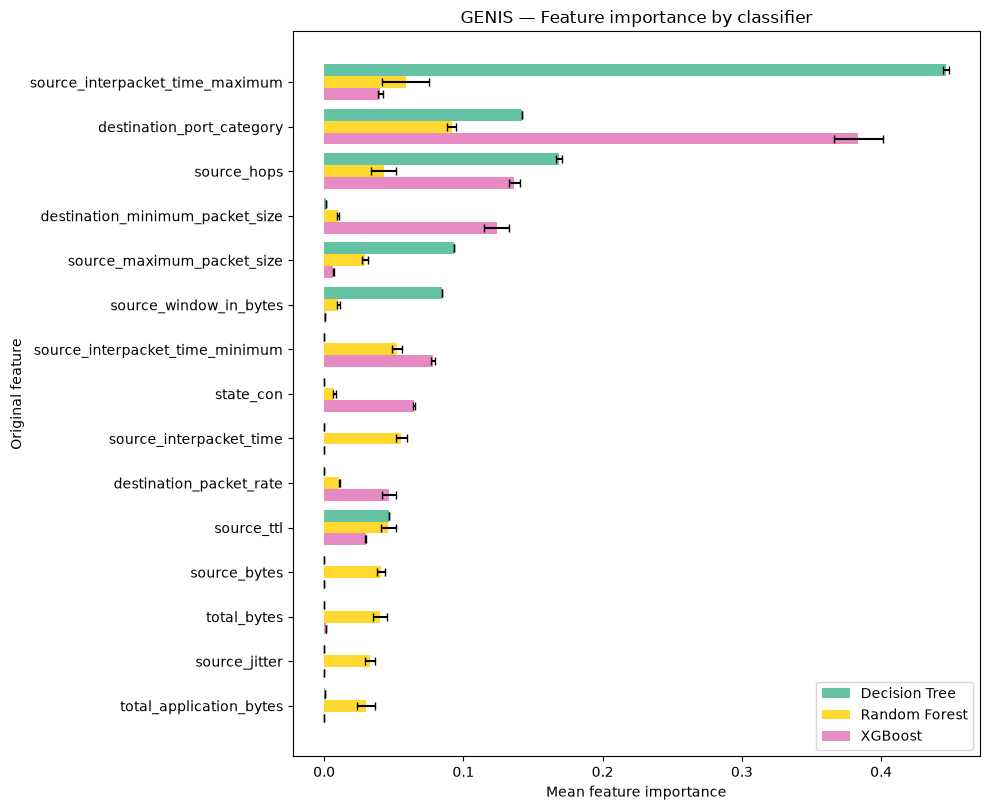

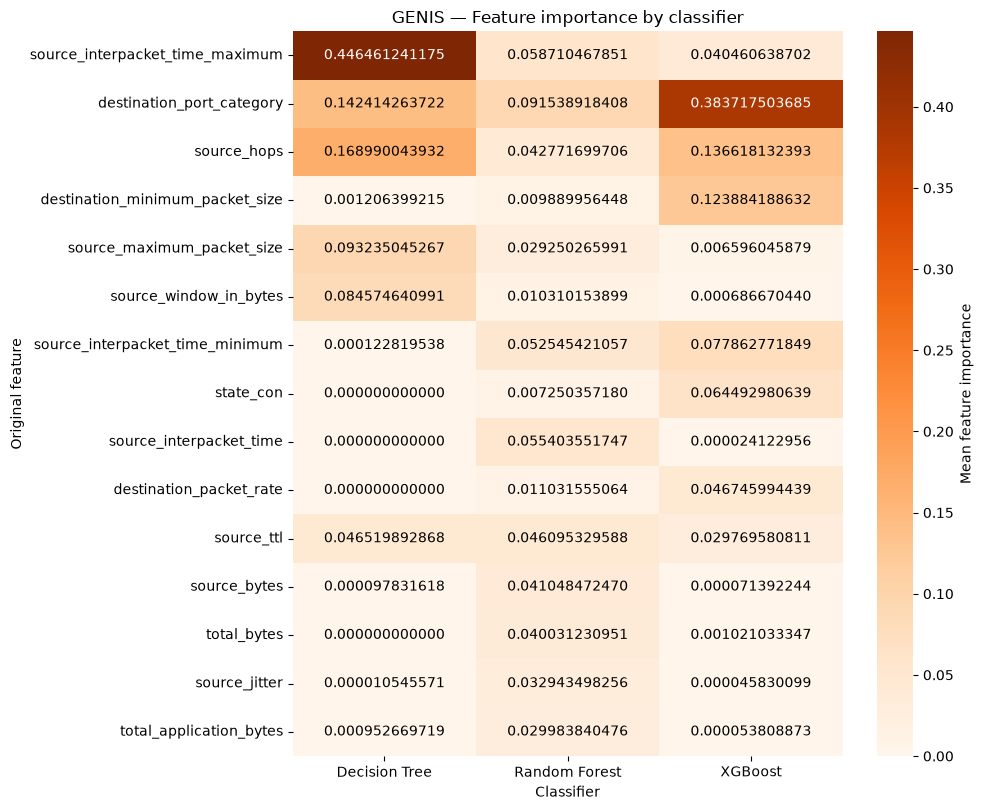

In [16]:
# ============================================================================
# Feature importance — aggregated across seeds
# ============================================================================


# ---------------------------------------------------------------------------
# Compile seed-aggregated original-feature importances
# ---------------------------------------------------------------------------

genis_feature_importances = compile_dataset_feature_importances(
    dataset_name=DATASET_NAME,
    artifacts_directory=ARTIFACTS_DIRECTORY,
)


# ---------------------------------------------------------------------------
# Feature-importance table
# ---------------------------------------------------------------------------

genis_feature_importance_table = prepare_dataset_feature_importance_table(
    genis_feature_importances,
)

display(genis_feature_importance_table)


# ---------------------------------------------------------------------------
# Top feature importances by classifier
# ---------------------------------------------------------------------------

figure = plot_dataset_feature_importances(
    feature_importances=genis_feature_importances,
    title=f"{DATASET_NAME} — Feature importance by classifier",
    top_n=DEFAULT_FEATURE_IMPORTANCE_TOP_N,
)

display(figure)
plt.close(figure)


# ---------------------------------------------------------------------------
# Top feature-importance heatmap
# ---------------------------------------------------------------------------

figure = plot_dataset_feature_importance_heatmap(
    feature_importances=genis_feature_importances,
    title=f"{DATASET_NAME} — Feature importance by classifier",
    top_n=DEFAULT_FEATURE_IMPORTANCE_TOP_N,
)

display(figure)
plt.close(figure)